## **Session 4** - Polynomial Linear Regression
در این نوع رگرسیون، تابع ما یک تابع چند جمله ای است. یعنی برخلاف رگرسیون خطی که تمام متغیر ها توان اول بودند اینجا توان های بیشتر از یک نیز داریم .

**Polynomial regression** introduces higher-order terms of the independent variable(s) into the regression equation. The general form of a polynomial regression model is: $$y = \beta_0 + \beta_1x + \beta_2x^2 + \beta_3x^3 + ... + \beta_nx^n + \epsilon$$

Where:

 - $y$ is the dependent variable
 - $x$ is the independent variable
 - $\beta_0, \beta_1, ..., \beta_n$ are the coefficients to be estimated
 - $n$ is the degree of the polynomial
 - $\epsilon$ is the error term

Polynomial regression offers several advantages over linear regression. Here are a few key benefits:

- **Flexibility:** Can model a wide range of non-linear relationships.
- **Interpretability:** The coefficients still have clear interpretations related to the curve's shape.
- **Simplicity:** Uses the same estimation techniques as linear regression (e.g., ordinary least squares).
While polynomial regression offers greater flexibility, it comes with risks:

- **Overfitting:** Higher-degree polynomials can fit the noise in the data, leading to poor generalization.
- **Extrapolation Issues:** Polynomial models can behave erratically outside the range of the training data.
- **Multicollinearity:** Higher-order terms can be highly correlated, potentially causing instability in coefficient estimates.



### Implementation
#### Feature Transformation


In [54]:
import numpy as np

def create_polynomial_features(X, degree):
    """
    Create polynomial features up to the specified degree.

    Args:
    X (np.array): Input features, shape (n_samples, 1)
    degree (int): Degree of the polynomial

    Returns:
    np.array: Polynomial features, shape (n_samples, degree)
    """
    n_samples = X.shape[0]
    X_poly = np.zeros((n_samples, degree))

    for i in range(1, degree + 1):
        X_poly[:, i-1] = X[:, 0] ** i

    return X_poly

In [55]:
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
X_poly = create_polynomial_features(X, 3)

In [56]:
X

array([[1],
       [2],
       [3],
       [4],
       [5]])

In [57]:
X_poly

array([[  1.,   1.,   1.],
       [  2.,   4.,   8.],
       [  3.,   9.,  27.],
       [  4.,  16.,  64.],
       [  5.,  25., 125.]])

#### Fitting Polynomial Models
Now that we can create polynomial features, let's implement the polynomial regression model:

In [58]:
import matplotlib.pyplot as plt

In [72]:
def fit_polynomial_regression(X, y, degree):
    """
    Fit a polynomial regression model.

    Args:
    X (np.array): Input features, shape (n_samples, 1)
    y (np.array): Target values, shape (n_samples, 1)
    degree (int): Degree of the polynomial

    Returns:
    np.array: Fitted coefficients, shape (degree + 1, 1)
    """
    X_poly = create_polynomial_features(X, degree)
    X_poly = np.c_[np.ones((X_poly.shape[0], 1)), X_poly]  # Add bias term
    coeffs = np.linalg.inv(X_poly.T.dot(X_poly)).dot(X_poly.T).dot(y)
    return coeffs

In [73]:
def predict_polynomial(X, coeffs):
    """
    Make predictions using the polynomial model.

    Args:
    X (np.array): Input features, shape (n_samples, 1)
    coeffs (np.array): Model coefficients, shape (degree + 1, 1)

    Returns:
    np.array: Predictions, shape (n_samples, 1)
    """
    degree = len(coeffs) - 1
    X_poly = create_polynomial_features(X, degree)
    X_poly = np.c_[np.ones((X_poly.shape[0], 1)), X_poly]
    return X_poly.dot(coeffs)


In [89]:
np.random.seed(0)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1) * 3

In [90]:
print("X:\n" , X)

X:
 [[ 0.        ]
 [ 0.1010101 ]
 [ 0.2020202 ]
 [ 0.3030303 ]
 [ 0.4040404 ]
 [ 0.50505051]
 [ 0.60606061]
 [ 0.70707071]
 [ 0.80808081]
 [ 0.90909091]
 [ 1.01010101]
 [ 1.11111111]
 [ 1.21212121]
 [ 1.31313131]
 [ 1.41414141]
 [ 1.51515152]
 [ 1.61616162]
 [ 1.71717172]
 [ 1.81818182]
 [ 1.91919192]
 [ 2.02020202]
 [ 2.12121212]
 [ 2.22222222]
 [ 2.32323232]
 [ 2.42424242]
 [ 2.52525253]
 [ 2.62626263]
 [ 2.72727273]
 [ 2.82828283]
 [ 2.92929293]
 [ 3.03030303]
 [ 3.13131313]
 [ 3.23232323]
 [ 3.33333333]
 [ 3.43434343]
 [ 3.53535354]
 [ 3.63636364]
 [ 3.73737374]
 [ 3.83838384]
 [ 3.93939394]
 [ 4.04040404]
 [ 4.14141414]
 [ 4.24242424]
 [ 4.34343434]
 [ 4.44444444]
 [ 4.54545455]
 [ 4.64646465]
 [ 4.74747475]
 [ 4.84848485]
 [ 4.94949495]
 [ 5.05050505]
 [ 5.15151515]
 [ 5.25252525]
 [ 5.35353535]
 [ 5.45454545]
 [ 5.55555556]
 [ 5.65656566]
 [ 5.75757576]
 [ 5.85858586]
 [ 5.95959596]
 [ 6.06060606]
 [ 6.16161616]
 [ 6.26262626]
 [ 6.36363636]
 [ 6.46464646]
 [ 6.56565657]
 [ 6.6

In [91]:
print("y:\n", y)

y:
 [[ 7.29215704]
 [ 3.30658325]
 [ 5.15864024]
 [ 9.07162358]
 [ 8.0883387 ]
 [-0.29924513]
 [ 5.63998059]
 [ 2.50297357]
 [ 2.82492155]
 [ 4.55410956]
 [ 3.95238375]
 [ 8.09121558]
 [ 6.2298533 ]
 [ 4.54031329]
 [ 5.74562908]
 [ 5.66401655]
 [ 9.40438802]
 [ 4.57603628]
 [ 6.41027749]
 [ 3.19855351]
 [-1.59815933]
 [ 8.33183834]
 [ 9.28466662]
 [ 4.79544148]
 [14.17198196]
 [ 3.35060566]
 [ 8.21216587]
 [ 7.88472944]
 [13.42621235]
 [13.62774777]
 [10.08651354]
 [11.16836165]
 [ 7.79292273]
 [ 4.94649948]
 [10.2879644 ]
 [12.25376275]
 [15.93880593]
 [16.32849451]
 [12.04299863]
 [12.79189799]
 [11.05717755]
 [10.45701588]
 [10.1226954 ]
 [21.62847148]
 [14.79203111]
 [15.56181015]
 [13.68289542]
 [20.34920405]
 [13.76069397]
 [18.56002424]
 [17.117906  ]
 [21.58127682]
 [19.5146206 ]
 [18.14180919]
 [22.24603183]
 [24.27264993]
 [23.85448484]
 [25.23983075]
 [23.11713371]
 [24.62976446]
 [24.40869763]
 [26.06571354]
 [25.43343127]
 [23.43272244]
 [29.89275185]
 [28.91423683]
 [25.9

#### Degree = 2

In [92]:
# fit polynomial regression model
degree = 2
coeffs = fit_polynomial_regression(X, y, degree)

In [94]:
print("coeffs:\n", coeffs)

coeffs:
 [[ 5.18925184]
 [-0.64319752]
 [ 0.65539995]]


In [95]:
X_test = np.linspace(0, 10, 200).reshape(-1, 1)
y_pred = predict_polynomial(X_test, coeffs)

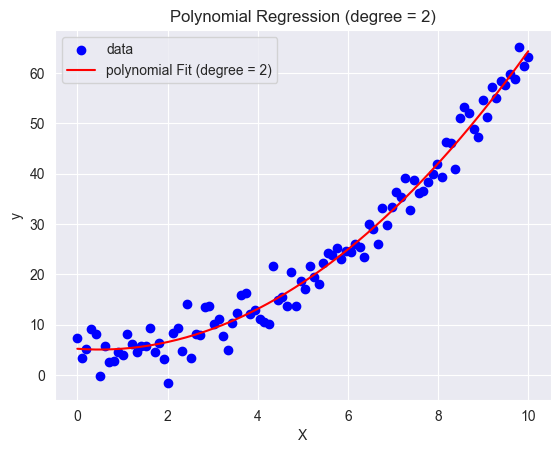

In [97]:
plt.scatter(X, y, color = 'blue', label = 'data')
plt.plot(X_test, y_pred, color = 'red', label = f"polynomial Fit (degree = {degree})")
plt.legend()
plt.title(f"Polynomial Regression (degree = {degree})")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### Degree = 1

In [98]:
degree = 1
coeffs = fit_polynomial_regression(X, y, degree)

In [99]:
X_test = np.linspace(0, 10, 200).reshape(-1, 1)
y_pred = predict_polynomial(X_test, coeffs)

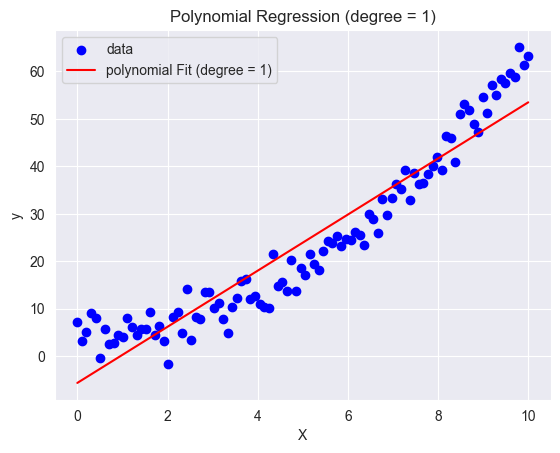

In [101]:
plt.scatter(X, y, color = 'blue', label = 'data')
plt.plot(X_test, y_pred, color = 'red', label = f"polynomial Fit (degree = {degree})")
plt.legend()
plt.title(f"Polynomial Regression (degree = {degree})")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

#### Degree = 10

In [104]:
degree = 10
coeffs = fit_polynomial_regression(X, y, degree)

In [105]:
X_test = np.linspace(0, 10, 200).reshape(-1, 1)
y_pred = predict_polynomial(X_test, coeffs)

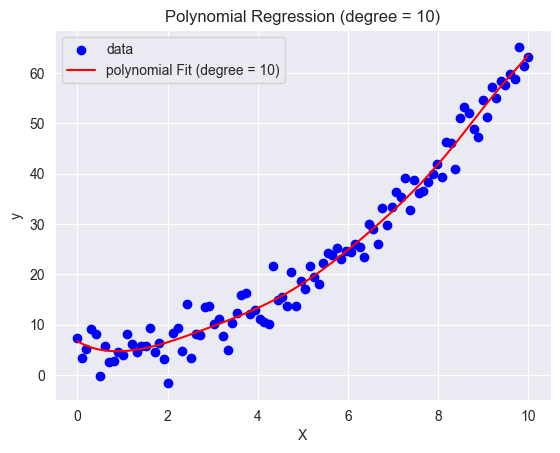

In [106]:
plt.scatter(X, y, color = 'blue', label = 'data')
plt.plot(X_test, y_pred, color = 'red', label = f"polynomial Fit (degree = {degree})")
plt.legend()
plt.title(f"Polynomial Regression (degree = {degree})")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

##### Tips
نکته: هرچه درجه را بالاتر ببریم مدل سازی دقت بالاتری پیدا می کند. البته این بالا بردن درجه تا یه حدی جواب میدهد و بعد از آن ساختار مدل سازی (مثلا در این مثال برای 12 به بالا) کلا از هم می پاشد.

---

**Tip:** This implementation uses the normal equation to find the coefficients. For large datasets, consider using gradient descent instead to improve computational efficiency.

### Overfitting in Polynomial Regression
این یکی از اساسی ترین و مهم ترین مشکلات در مدل سازی های ماشین لرنینگ است.

تعریف: حالتی که مدل، داده‌های آموزشی را بیش از حد یاد می‌گیرد و به جای الگوهای کلی، جزئیات و نویزهای تصادفی را هم حفظ می‌کند.

![](Images/img_3.png)

نشانه‌ها:

- عملکرد عالی روی داده‌های آموزشی (خطای کم)

- عملکرد ضعیف روی داده‌های جدید یا تست (خطای زیاد)

- مدل بیش از حد پیچیده است (مثلاً درجه بالای چندجمله‌ای)

مثال: در رگرسیون چندجمله‌ای، درجه ۲۰ روی ۱۰ نقطه داده، منحنی را طوری می‌کشد که از همه نقاط عبور کند اما برای پیش‌بینی نقاط جدید کاملاً بی‌استفاده است.

راه‌های جلوگیری:

- استفاده از داده‌های بیشتر

- ساده‌تر کردن مدل (کاهش درجه یا پیچیدگی)

- اعمال Regularization (منظم‌سازی)

- استفاده از Cross-Validation (اعتبارسنجی متقابل)



### Practical Considerations and Best Practices
با استفاده از روش های زیر می توان از $Overfitting$ جلوگیری کرد

#### 1. Choosing the Right Polynomial Degree
#### 2. Feature Scaling

Polynomial features can quickly lead to large value ranges

To address this:

1. **Normalize Features:** Scale your input features before creating polynomial terms.
2. **Use Mean Normalization or Min-Max Scaling:** These techniques can help bring all features to a similar scale.

#### 3. Interpreting Polynomial Regression Results
#### 4. Extrapolation Caution
بهتر است بررسی ها داخل بازه مجاز باشد.

یعنی باید داده های تست داخل بازه داده های آموزش باشند

#### 5. Computational Considerations
As the degree of the polynomial increases, so does the computational complexity:

1. **Balance Complexity:** Higher-degree polynomials require more computation time and memory.
2. **Consider Alternatives:** For very high-dimensional data, consider other non-linear modeling techniques that may be more efficient.